In [456]:
## Import all the libraries I need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px 
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import seaborn as sns
import pickle

import warnings
warnings.filterwarnings('ignore')

## Import functions from sklearn for building the model, training-testing split, visualising the model and metrics 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree


In [457]:
## importing the dataset
df = pd.read_csv('data/Churn_Modelling.csv')

In [458]:
df.head()   

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [459]:
## RowNumber --> This is just an index and does not provide any useful information for the model, so we can drop it.
## CustomerId --> This is a unique identifier for each customer and does not provide any useful information for the model, so we can drop it.
## Surname --> This is a unique identifier for each customer and does not provide any useful information for the model, so we can drop it.
## Geography --> This is a categorical variable that indicates the country of residence of the customer. We can convert this variable into dummy variables (one-hot encoding) to use it in our model.
## Gender --> This is a categorical variable that indicates the gender of the customer. We can convert this variable into dummy variables (one-hot encoding) to use it in our model.
## CreditScore --> This is a numerical variable that indicates the credit score of the customer. We can use this variable as it is in our model.
## Age --> This is a numerical variable that indicates the age of the customer. We can use this variable as it is in our model.
## Tenure --> This is a numerical variable that indicates the number of years the customer has been with the bank. We can use this variable as it is in our model.
## Balance --> This is a numerical variable that indicates the balance of the customer's account. We can use this variable as it is in our model.
## NumOfProducts --> This is a numerical variable that indicates the number of products the customer has with the bank. We can use this variable as it is in our model.
## HasCrCard --> This is a binary variable that indicates whether the customer has a credit card or not. We can use this variable as it is in our model.
## IsActiveMember --> This is a binary variable that indicates whether the customer is an active member or not. We can use this variable as it is in our model.
## EstimatedSalary --> This is a numerical variable that indicates the estimated salary of the customer. We can use this variable as it is in our model.
## Exited --> This is the target variable that indicates whether the customer has churned or not. We can use this variable as it is in our model. 
## Depentent Variable/ Target Variable(Exited): 1 indicates that the customer has churned, while 0 indicates that the customer has not churned.


In [460]:
df.shape ## (10000, 14)

(10000, 14)

In [461]:
## The dataset has 10,000 rows and 14 columns.
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [462]:
df.isnull().sum() ## There are no missing values in the dataset.

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [463]:
df.describe() ## The dataset has a wide range of values for the numerical variables, which may require scaling before training the model.

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [464]:
## Preprocess the data
df = df.drop(["RowNumber","CustomerId","Surname",], axis=1) # droping coulmn from the feature 

In [465]:
df["Exited"].value_counts() ## The target variable is imbalanced, with more customers who have not churned than those who have churned. This may require techniques such as oversampling or undersampling to balance the classes before training the model.

Exited
0    7963
1    2037
Name: count, dtype: int64

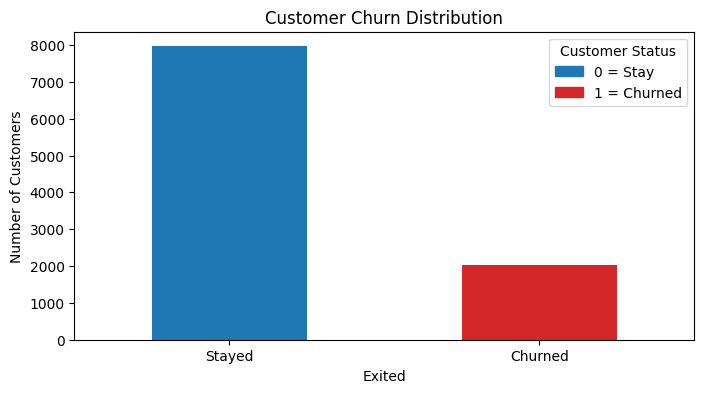

In [466]:
## Exploratory Data Analysis (EDA)

plt.figure(figsize=(8,4))

ax = df["Exited"].value_counts().sort_index().plot(
    kind='bar',
    color=['#1f77b4','#d62728']
)

plt.title('Customer Churn Distribution')
plt.xlabel('Exited')
plt.ylabel('Number of Customers')

plt.xticks([0,1], ['Stayed','Churned'], rotation=0)

# Create custom legend
stay_patch = mpatches.Patch(color='#1f77b4', label='0 = Stay')
leave_patch = mpatches.Patch(color='#d62728', label='1 = Churned')

plt.legend(handles=[stay_patch, leave_patch], title='Customer Status')

plt.show()

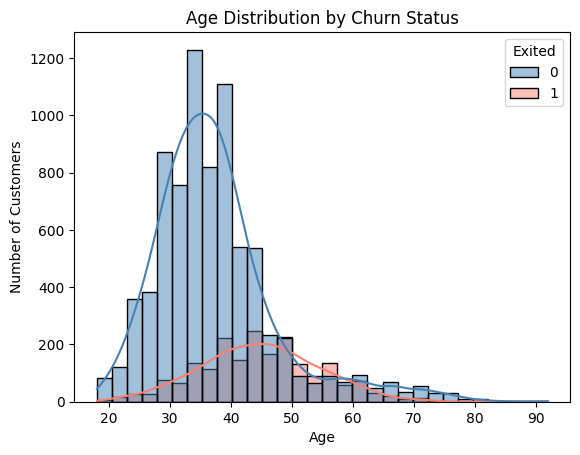

In [467]:
df.groupby('Exited')['Age'].mean() ## The average age of customers who have churned is higher than that of customers who have not churned, suggesting that older customers may be more likely t

## visualise the distribution of age for customers who have churned and those who have not churned using a histogram.
sns.histplot(
    data=df,
    x='Age',
    hue='Exited',
    bins=30,
    kde=True,
    palette=['steelblue','salmon']
)

plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

In [468]:
df.groupby('Exited')['Tenure'].mean() # The average tenure of customers who have churned is lower than that of customers who have not churned, suggesting that customers who have been with the bank for a shorter period of time may be more likely to churn.

Exited
0    5.033279
1    4.932744
Name: Tenure, dtype: float64

In [469]:
df.groupby(['Exited', 'Gender'])['Balance'].mean()
## The average balance of customers who have churned is higher than that of customers who have not churned, suggesting that customers with higher balances may be more likely to churn. 
## Additionally, the average balance for male customers who have churned is higher than that for female customers who have churned.

Exited  Gender
0       Female    71183.249639
        Male      73911.607037
1       Female    89036.639359
        Male      93736.483742
Name: Balance, dtype: float64

In [470]:
## Plotting the distribution of customers by geography and churn status

df1 = df.copy() ## create a copy of the original dataframe to perform EDA without modifying the original data
df1["Churn_Label"] = df1["Exited"].map({0: "Stayed", 1: "Churned"}) ## create a new column "Churn_Label" that maps the values of the "Exited" column to "Stayed" and "Left" for better visualization

fig = px.histogram(
    df1,
    x="Geography",
    color="Churn_Label",
    barmode="group",
    text_auto=True,
    title="Customer Churn by Geography",
    color_discrete_map={
        "Stayed": "#1f77b4",   
        "Churned": "#d62728"   
    }

)
fig.update_layout(
    width=800,
    height=500,
    legend_title_text="",
    xaxis_title="Geography",
    yaxis_title="Number of Customers"
)

fig.show()

In [471]:
df.groupby('Exited')['Balance'].mean() ## The average balance of customers who have churned is higher than that of customers who have not churned, suggesting that customers with higher balances may be more likely to churn.

Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

In [472]:
## Plotting the distribution of customers by tenure and churn status
# Create tenure groups FIRST
df1["Churn_Label"] = df1["Exited"].map({0: "Stayed", 1: "Churned"})
df1['Tenure_group'] = pd.cut(
    df1['Tenure'],
    bins=[0,2,5,8,10],
    labels=['0-2','3-5','6-8','9-10']
)

# Then plot
fig = px.histogram(
    df1,
    x='Tenure_group',
    color='Churn_Label',
    text_auto=True,
    barmode='group',
    color_discrete_map={"Stayed": "#1f77b4", "Churned": "#d62728"},
    labels={
        'Churn_Label': 'Customer Status',
        'Tenure_group': 'Tenure Group (Years)'
    },
    title='Customer Churn by Tenure Group'
)

fig.update_layout(
    width=800,
    height=500,
    legend_title_text='Churn Status',
    yaxis_title='Number of Customers')

fig.show()

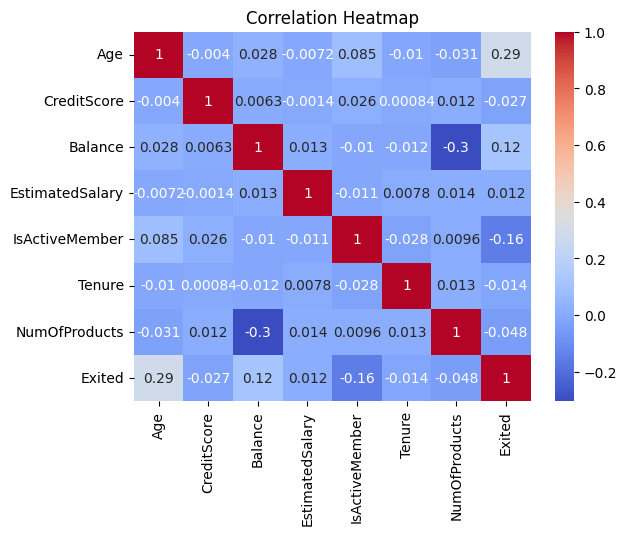

In [473]:
## Correlation heatmap to visualize the relationships between the numerical variables and the target variable (Exited)

correlation_matrix = df[['Age','CreditScore', 'Balance','EstimatedSalary','IsActiveMember','Tenure','NumOfProducts', 'Exited']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [474]:
# Feature Engineering 
# X_features = df.drop(["RowNumber","CustomerId","Surname","Exited"], axis=1) # droping coulmn from the feature 
# y_target = df.Exited # the target

In [475]:
df.head(6)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1


In [476]:
## Feature Scaling and Encoding

## The dataset contains both numerical and categorical variables. We need to encode the categorical variables before we can use them in our machine learning model.
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pickle ## Pickle is commonly used to save machine learning models after training, so that they can be loaded and used later without having to retrain the model.



le_gender =LabelEncoder() ## Encode categorical variables
df['Gender']= le_gender.fit_transform(df['Gender']) ## This would change the Columns to Zeros(0) and Ones(1)
df.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0


In [477]:
## One-hot encode the 'Geography' column
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(df[['Geography']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Geography'])
)

## Concatenate the original DataFrame with the encoded DataFrame and drop the original 'Geography' column
df = pd.concat([df.drop('Geography', axis=1), encoded_df], axis=1)
df.head(5)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [478]:
## Divide the data to indepent and dependent variable, X--> independent variable and y--> dependent variable
X = df.drop('Exited', axis=1) # Features
y = df['Exited'] # Target variable

## Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

LogisticRegression Precision: 43.08%
LogisticRegression Recall: 6.88%
LogisticRegression F1 Score: 11.86%
LogisticRegression Accuracy: 79.20%

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.98      0.88      1593
           1       0.43      0.07      0.12       407

    accuracy                           0.79      2000
   macro avg       0.62      0.52      0.50      2000
weighted avg       0.73      0.79      0.73      2000


Confusion Matrix:
 [[1556   37]
 [ 379   28]]


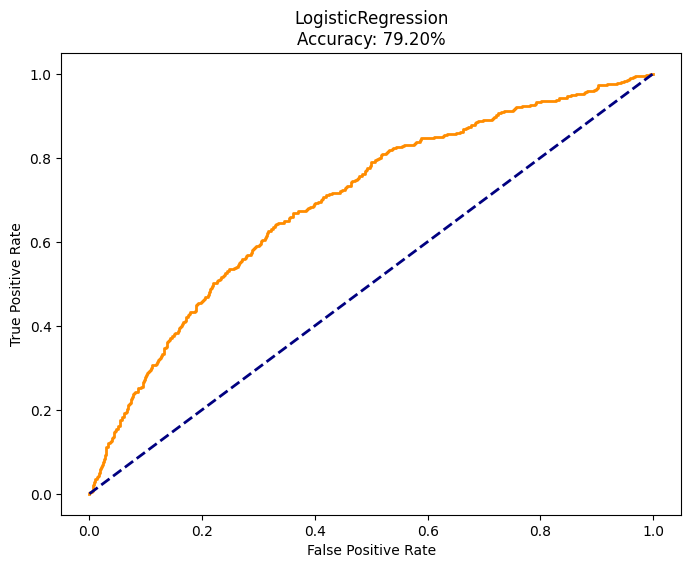

In [479]:
## First model: Logistic Regression

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
# from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

lraccuracy = accuracy_score(y_test, y_pred)
print("LogisticRegression Precision: {:.2f}%".format(precision_score(y_test, y_pred) * 100))
print("LogisticRegression Recall: {:.2f}%".format(recall_score(y_test, y_pred) * 100))
print("LogisticRegression F1 Score: {:.2f}%".format(f1_score(y_test, y_pred) * 100))
print("LogisticRegression Accuracy: {:.2f}%".format(lraccuracy * 100))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

## visualization
y_prob = lr_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LogisticRegression\nAccuracy: {:.2f}%'.format(lraccuracy * 100))
plt.show()


In [480]:
from sklearn.utils.class_weight import compute_class_weight
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

In [481]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}
lr = LogisticRegression(max_iter=1000)

grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best parameters:", grid_lr.best_params_)
print("Best f1:", grid_lr.best_score_)

Best parameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best f1: 0.31509816685000297


In [482]:
X.head(5)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0.0,0.0,1.0


In [483]:
# Now we will make predictions for two hypothetical customers using the trained logistic regression model. 
# We will create a DataFrame with the same structure as the training data, and then use the model to predict whether these customers are likely to churn or not.

# test_customers = [
#     {
#         "CreditScore": 619,
#         "Age": 42,
#         "Tenure": 2,
#         "Balance": 0,
#         "NumOfProducts": 1,
#         "EstimatedSalary": 101348.88,
#         "HasCrCard": 1,
#         "IsActiveMember": 1,
#         "Gender": 1,
#         "Geography_France": 1,
#         "Geography_Germany": 0,
#         "Geography_Spain": 0
#     },
#     {
#         "CreditScore": 750,
#         "Age": 50,
#         "Tenure": 10,
#         "Balance": 150000,
#         "NumOfProducts": 2,
#         "EstimatedSalary": 120000,
#         "HasCrCard": 1,
#         "IsActiveMember": 0,
#         "Gender": 0,
#         "Geography_France": 0,
#         "Geography_Germany": 1,
#         "Geography_Spain": 0
#     }
# ]

# test_df = pd.DataFrame(test_customers)

# # make column order exactly match training data
# test_df = test_df[X.columns]

# # Make predictions using the trained logistic regression model

# predictions = lr_model.predict(test_df)
# probabilities = lr_model.predict_proba(test_df)[:, 1]  # Probability of the positive class (churn)

# print(predictions)
# print(probabilities)

LogisticRegression Precision: 47.76%
LogisticRegression Recall: 52.33%
LogisticRegression F1 Score: 49.94%
LogisticRegression Accuracy: 78.65%

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.86      1593
           1       0.48      0.52      0.50       407

    accuracy                           0.79      2000
   macro avg       0.68      0.69      0.68      2000
weighted avg       0.79      0.79      0.79      2000


Confusion Matrix:
 [[1360  233]
 [ 194  213]]
ROC AUC Score: 77.99%


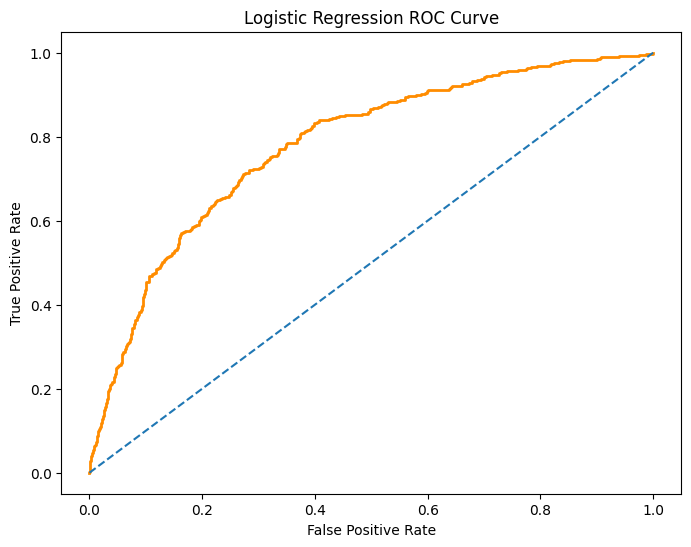

Best parameters: {'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best f1: 0.4870518130181252


In [484]:
pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.6,random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

lr_model2 = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

lr_model2.fit(X_train, y_train)

y_pred_lr2 = lr_model2.predict(X_test)

lr2_accuracy = accuracy_score(y_test, y_pred_lr2)

print("LogisticRegression Precision: {:.2f}%".format(precision_score(y_test, y_pred_lr2) * 100))
print("LogisticRegression Recall: {:.2f}%".format(recall_score(y_test, y_pred_lr2) * 100))
print("LogisticRegression F1 Score: {:.2f}%".format(f1_score(y_test, y_pred_lr2) * 100))
print("LogisticRegression Accuracy: {:.2f}%".format(lr2_accuracy * 100))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr2))
print("ROC AUC Score: {:.2f}%".format(roc_auc_score(y_test, lr_model2.predict_proba(X_test)[:, 1]) * 100))

# ROC curve
y_prob_pipe = lr_model2.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred = (y_prob > threshold).astype(int)
fpr_pipe, tpr_pipe, thresholds_pipe = roc_curve(y_test, y_prob_pipe)

plt.figure(figsize=(8,6))
plt.plot(fpr_pipe, tpr_pipe, color="darkorange", lw=2)
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")

plt.show()

print("Best parameters:", lr_model2.best_params_)
print("Best f1:", lr_model2.best_score_)

Decision Tree Precision: 48.21%
Decision Tree Recall: 52.83%
Decision Tree F1 Score: 50.41%
Decision Tree Accuracy: 78.85%

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.87      1593
           1       0.48      0.53      0.50       407

    accuracy                           0.79      2000
   macro avg       0.68      0.69      0.68      2000
weighted avg       0.80      0.79      0.79      2000


Confusion Matrix:
 [[1362  231]
 [ 192  215]]
ROC AUC Score: 69.16%


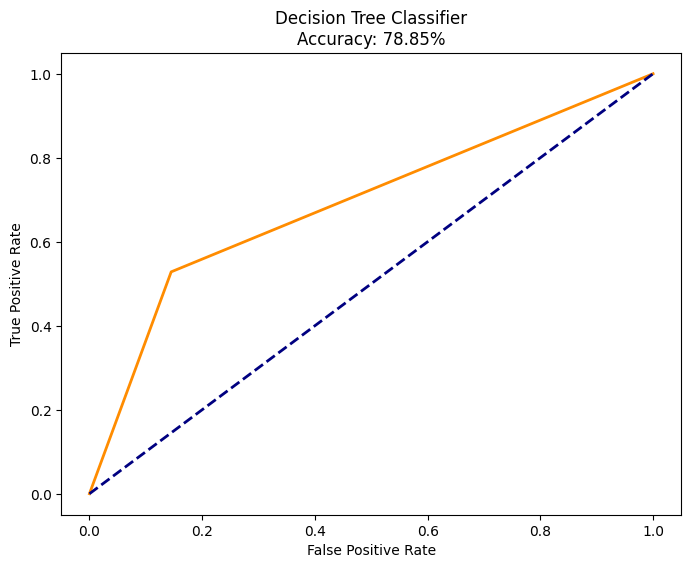

In [485]:
## Second Model: Decision Tree Classifier

dt_model = DecisionTreeClassifier(
    random_state=42
    
)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)


print("Decision Tree Precision: {:.2f}%".format(precision_score(y_test, y_pred_dt) * 100))
print("Decision Tree Recall: {:.2f}%".format(recall_score(y_test, y_pred_dt) * 100))
print("Decision Tree F1 Score: {:.2f}%".format(f1_score(y_test, y_pred_dt) * 100))
print("Decision Tree Accuracy: {:.2f}%".format(dt_accuracy * 100))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("ROC AUC Score: {:.2f}%".format(roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1]) * 100))
# visualization
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree Classifier\nAccuracy: {:.2f}%'.format(dt_accuracy * 100))
plt.show()

In [486]:
dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring=["f1","recall"],
    refit="f1",
    cv=5,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best parameters:", grid_dt.best_params_)
print("Best F1 score:", grid_dt.best_score_)
print("Best Recall score:", grid_dt.cv_results_["mean_test_recall"][grid_dt.best_index_])

Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best F1 score: 0.5779220891369412
Best Recall score: 0.5104294478527607


RandomForestClassifier Accuracy: 86.30%
RandomForestClassifier Precision: 77.59%
RandomForestClassifier Recall: 45.95%
RandomForestClassifier F1 Score: 57.72%

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000

Confusion Matrix:
 [[1539   54]
 [ 220  187]]
ROC AUC Score: 85.58%


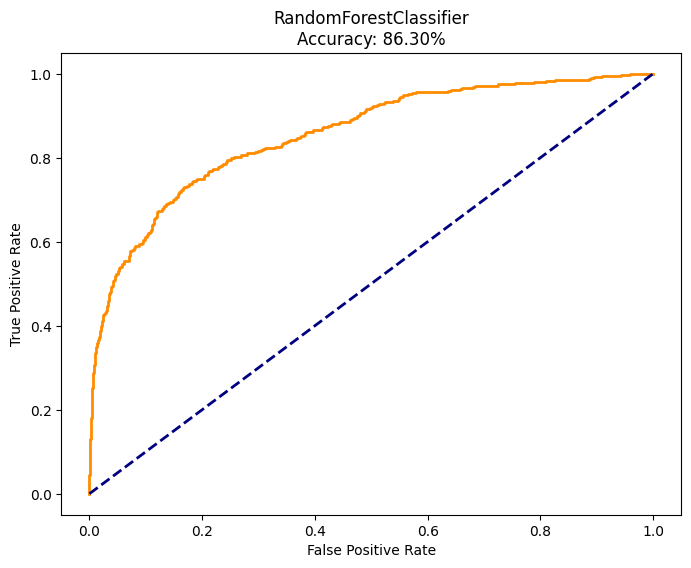

In [487]:
## Third Model: RandomForestClassifier

rf_clf = RandomForestClassifier(
    
    max_depth=None,
    max_features= 'sqrt', 
    min_samples_leaf= 2,
    min_samples_split= 2,
    n_estimators=300,
)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("RandomForestClassifier Accuracy: {:.2f}%".format(rf_accuracy * 100))
print("RandomForestClassifier Precision: {:.2f}%".format(precision_score(y_test, y_pred_rf) * 100))
print("RandomForestClassifier Recall: {:.2f}%".format(recall_score(y_test, y_pred_rf) * 100))
print("RandomForestClassifier F1 Score: {:.2f}%".format(f1_score(y_test, y_pred_rf) * 100))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("ROC AUC Score: {:.2f}%".format(roc_auc_score(y_test, rf_clf.predict_proba(X_test)[:, 1]) * 100))

## visualization 
y_prob = rf_clf.predict_proba(X_test)[:, 1]
#threshold = 0.35
#y_pred = (y_prob > threshold).astype(int)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('RandomForestClassifier\nAccuracy: {:.2f}%'.format(rf_accuracy * 100))
plt.show()

GradientBoostingClassifier Precision: 63.52%
GradientBoostingClassifier Recall: 62.90%
GradientBoostingClassifier F1 Score: 63.21%
Accuracy: 85.10%

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91      1593
           1       0.64      0.63      0.63       407

    accuracy                           0.85      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000

Confusion Matrix:
 [[1446  147]
 [ 151  256]]
ROC AUC Score: 87.02%


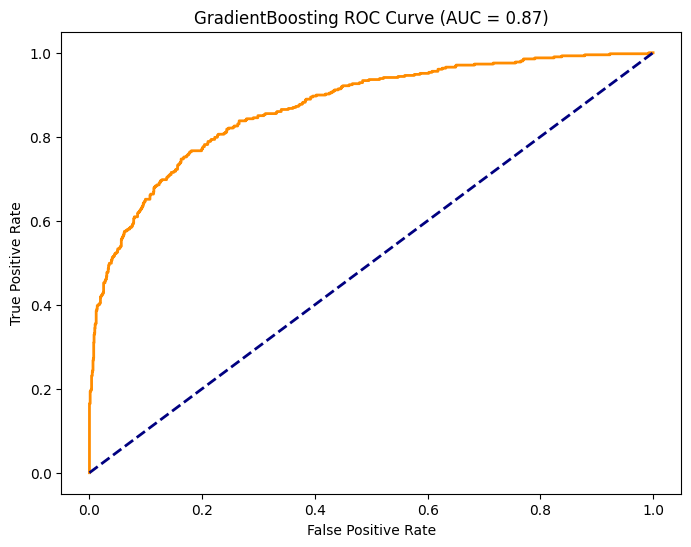

In [488]:
## Fourth Model: GradientBoostingClassifier
gb_clf = GradientBoostingClassifier(
    # learning_rate=0.1,
    # max_depth=4,
    # min_samples_leaf=1,
    # min_samples_split=2,
    # n_estimators=300

)
gb_clf.fit(X_train, y_train)

y_prob = gb_clf.predict_proba(X_test)[:, 1]         ## Get the predicted probabilities for the positive class (churned customers)


threshold = 0.31                                    ## adjust threshold to improve recall

y_pred_gb= (y_prob > threshold).astype(int)
auc = roc_auc_score(y_test, y_prob)
gb_accuracy = accuracy_score(y_test, y_pred_gb)


print("GradientBoostingClassifier Precision: {:.2f}%".format(precision_score(y_test, y_pred_gb) * 100))
print("GradientBoostingClassifier Recall: {:.2f}%".format(recall_score(y_test, y_pred_gb) * 100))
print("GradientBoostingClassifier F1 Score: {:.2f}%".format(f1_score(y_test, y_pred_gb) * 100))
print("Accuracy: {:.2f}%".format(gb_accuracy * 100))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("ROC AUC Score: {:.2f}%".format(auc * 100))

## visualization
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f"GradientBoosting ROC Curve (AUC = {auc:.2f})")
plt.show()

## save the best model using pickle
with open('best_model.pkl', 'wb') as file:
    pickle.dump(gb_clf, file)

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000281 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 859
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
Threshold: 0.35
Accuracy: 85.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.91      0.91      1593
           1       0.64      0.61      0.62       407

    accuracy                           0.85      2000
   macro avg       0.77      0.76      0.76      2000
weighted avg       0.85      0.85      0.85      2000

Confusion Matrix:
 [[1453  140]
 [ 160  247]]
F1 Score: 62.22%
ROC AUC Score: 0.86


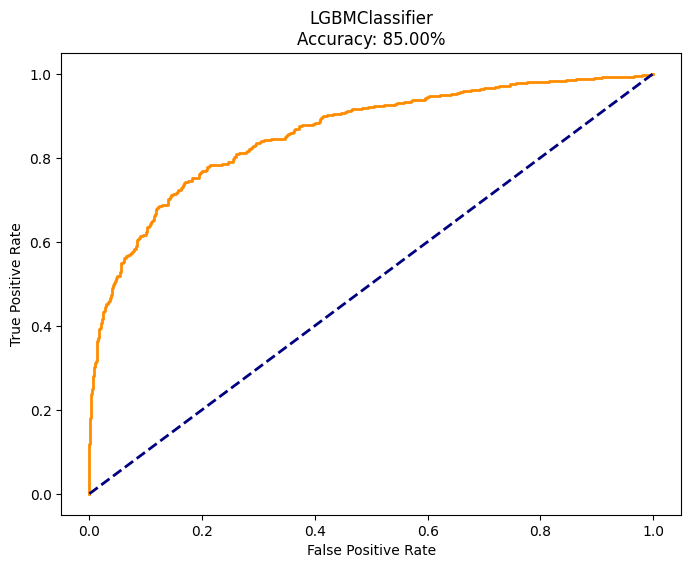

In [489]:
from lightgbm import LGBMClassifier
## Fifth model: LGBMClassifier
lgbm = LGBMClassifier(
    # num_leaves=35,
    # n_estimators=100,
    # max_depth=-1,
    # learning_rate=0.01,
    # colsample_bytree=0.8,
    # subsample=0.8,
    # random_state=42
)

lgbm.fit(X_train, y_train)
y_prob = lgbm.predict_proba(X_test)[:,1]


threshold = 0.35
y_pred = (y_prob > threshold).astype(int)

lgbm_accuracy = accuracy_score(y_test, y_pred)
roc_auc_lgbm = roc_auc_score(y_test, y_prob)

print("Threshold:", threshold)
print("Accuracy: {:.2f}%".format(lgbm_accuracy * 100))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("F1 Score: {:.2f}%".format(f1_score(y_test, y_pred) * 100))
print("ROC AUC Score: {:.2f}".format(roc_auc_lgbm))


## visualization
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LGBMClassifier\nAccuracy: {:.2f}%'.format(lgbm_accuracy * 100))
plt.show()

In [490]:
from matplotlib import scale
from xgboost import XGBClassifier
# scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() ## This parameter increases the penalty for misclassifying the positive class (churn), which helps when the dataset is imbalanced.

# ## Sixth Model: XGBoost Classifier
# xgb_model = XGBClassifier(
#     # scale_pos_weight=scale_pos_weight,
#     n_estimators=200,
#     max_depth=5,
#     learning_rate=0.01,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     eval_metric="logloss"
# )

# xgb_model.fit(X_train, y_train)                     ## train the model

# y_pred = xgb_model.predict(X_test)                  ## make predictions on the test set
# y_proba = xgb_model.predict_proba(X_test)[:, 1]
# y_pred_adjusted = (y_proba > 0.35).astype(int)
# xgb_accuracy = accuracy_score(y_test, y_pred_adjusted)

# print("XGBoost Accuracy: {:.2f}%".format(xgb_accuracy * 100)) # 8) evaluate the model's performance using accuracy, classification report, ROC AUC score, and confusion matrix
# print(classification_report(y_test, y_pred_adjusted))
# print("ROC AUC Score: {:.2f}".format(roc_auc_score(y_test, y_proba)))
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# ## visualization
# fpr, tpr, thresholds = roc_curve(y_test, y_proba)  
# plt.figure(figsize=(8, 6))
# plt.plot(fpr, tpr, color='darkorange', lw=2)
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('XGBoost Classifier\nAccuracy: {:.2f}%'.format(xgb_accuracy * 100))
# plt.show()  


XGBoost Accuracy: 85.50%
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1593
           1       0.65      0.62      0.64       407

    accuracy                           0.85      2000
   macro avg       0.78      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000

ROC AUC Score: 0.86
Confusion Matrix:
 [[1525   68]
 [ 207  200]]
F1 Score: 63.66%


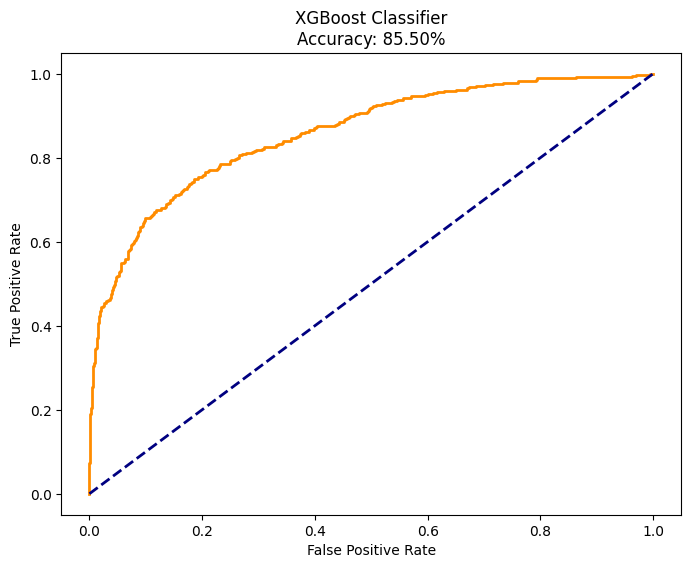

In [491]:
## Sixth Model: XGBoost Classifier
xgb_model = XGBClassifier(
    # scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)                     ## train the model

y_pred = xgb_model.predict(X_test)                  ## make predictions on the test set
y_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred_adjusted = (y_proba > 0.35).astype(int)
xgb_accuracy = accuracy_score(y_test, y_pred_adjusted)

print("XGBoost Accuracy: {:.2f}%".format(xgb_accuracy * 100)) # 8) evaluate the model's performance using accuracy, classification report, ROC AUC score, and confusion matrix
print(classification_report(y_test, y_pred_adjusted))
print("ROC AUC Score: {:.2f}".format(roc_auc_score(y_test, y_proba)))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("F1 Score: {:.2f}%".format(f1_score(y_test, y_pred_adjusted) * 100))
## visualization
fpr, tpr, thresholds = roc_curve(y_test, y_proba)  
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost Classifier\nAccuracy: {:.2f}%'.format(xgb_accuracy * 100))
plt.show()  

In [492]:
# best_model = grid.best_estimator_

# y_pred = best_model.predict(X_test)
# y_prob = best_model.predict_proba(X_test)[:,1]

In [493]:
# predict with xgboost
# predictions = xgb_model.predict(test_df)
# probabilities = xgb_model.predict_proba(test_df)

# print(predictions)
# print(probabilities)
# The above test_df contains two hypothetical customers with their respective features. 
# The predictions variable will contain the predicted class (0 for not churn, 1 for churn) for each customer, while the probabilities variable will contain the predicted probabilities for each class.

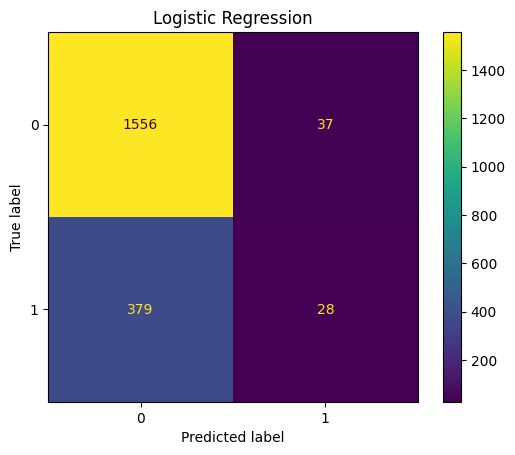

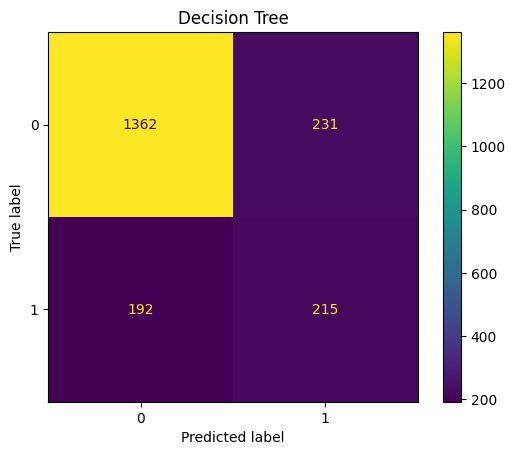

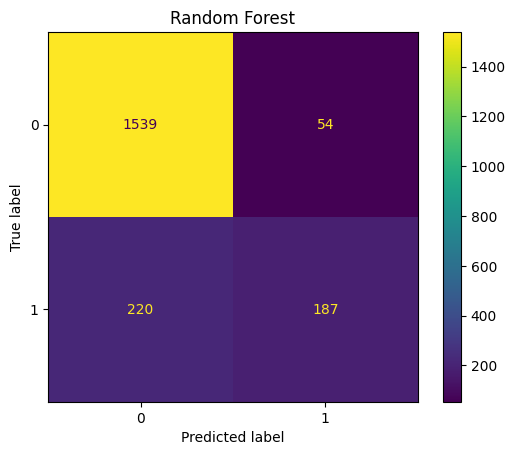

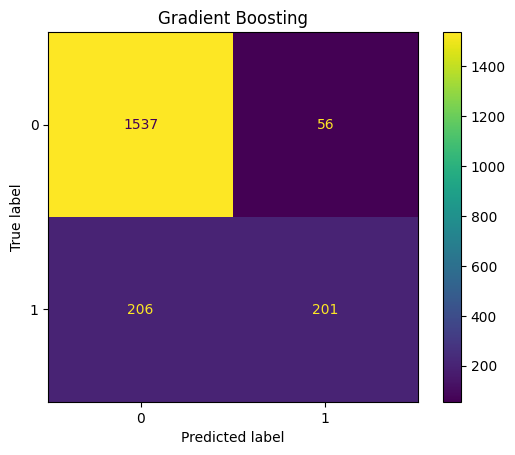

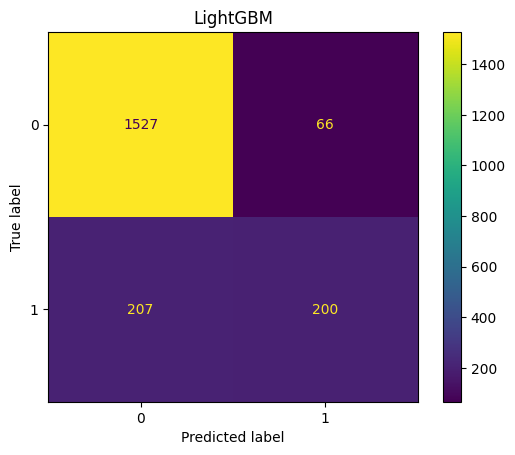

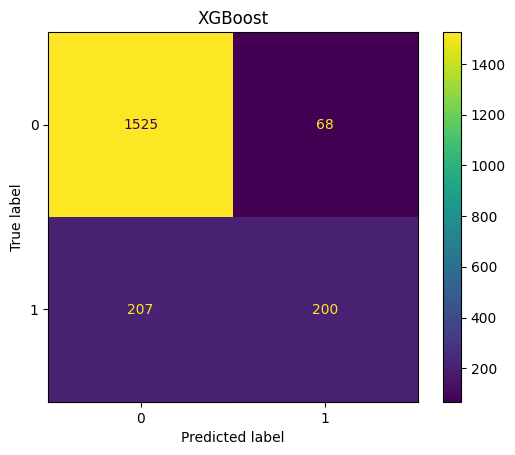

In [494]:
models = {
    "Logistic Regression": (lr_model, X_test),
    "Decision Tree": (dt_model, X_test),
    "Random Forest": (rf_clf, X_test),
    "Gradient Boosting": (gb_clf, X_test),
    "LightGBM": (lgbm, X_test),
    "XGBoost": (xgb_model, X_test)
}

for name, (model, X) in models.items():
    y_pred = model.predict(X)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name)
    plt.show()

In [495]:
model_results = {
    "Logistic Regression": lr2_accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy,
    "Gradient Boosting": gb_accuracy,
    "LightGBM": lgbm_accuracy,
    "XGBoost": xgb_accuracy,
    
}

In [496]:
results_df = pd.DataFrame(list(model_results.items()), columns=["Model", "Accuracy"])

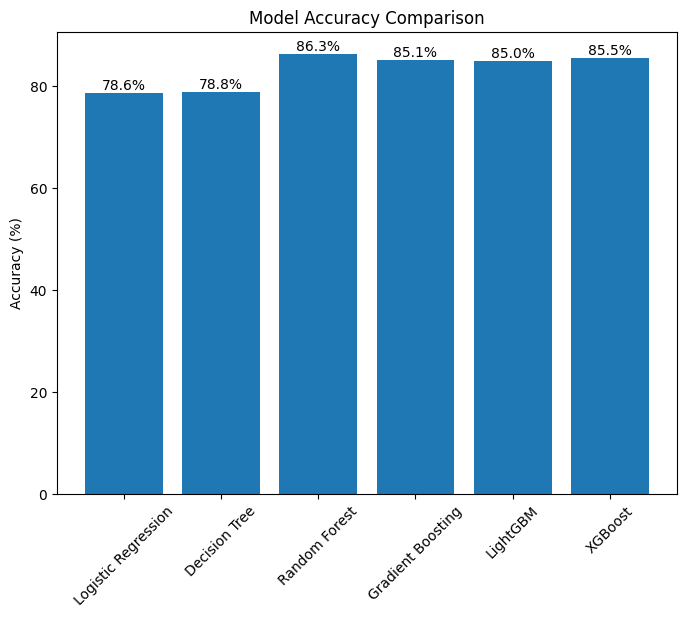

In [497]:
# Create a bar plot to compare the accuracy of the models

plt.figure(figsize=(8,6))

bars = plt.bar(results_df["Model"], results_df["Accuracy"] * 100)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)

# add percentage values
plt.bar_label(bars, fmt="%.1f%%")

plt.show()

In [498]:

# plt.figure(figsize=(8,6))
# sns.barplot(x="Model", y="Accuracy", data=results_df)

# plt.title("Model Performance Comparison")
# plt.xticks(rotation=45)
# plt.show()

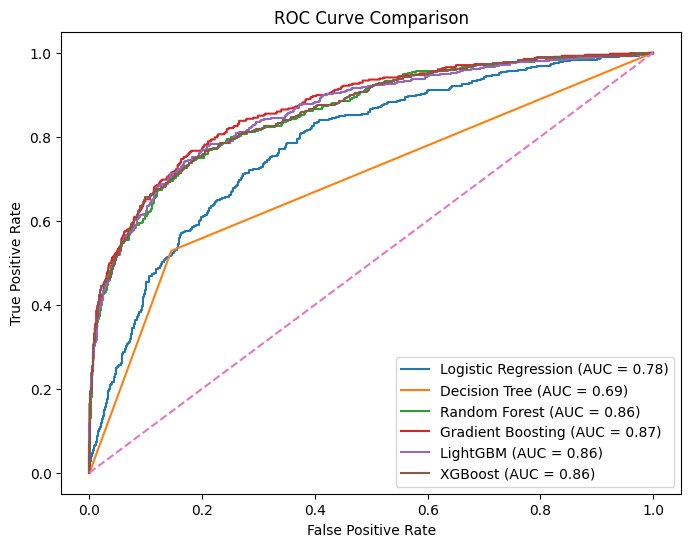

In [499]:
## roc curve comparison for all models

models = {
    "Logistic Regression": lr_model2,
    "Decision Tree": dt_model,
    "Random Forest": rf_clf,
    "Gradient Boosting": gb_clf,
    "LightGBM": lgbm,
    "XGBoost": xgb_model
}

## visualize feature importance for each model
plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [500]:
results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy
2,Random Forest,0.8630
5,XGBoost,0.8550
3,Gradient Boosting,0.8510
4,LightGBM,0.8500
1,Decision Tree,0.7885
0,Logistic Regression,0.7865


In [501]:
results_df["Accuracy (%)"] = results_df["Accuracy"] * 100
results_df = results_df.drop(columns="Accuracy")

In [502]:
results_df["Accuracy (%)"] = results_df["Accuracy (%)"].round(2)
results_df

,Model,Accuracy (%)
2,Random Forest,86.30
5,XGBoost,85.50
3,Gradient Boosting,85.10
4,LightGBM,85.00
1,Decision Tree,78.85
0,Logistic Regression,78.65


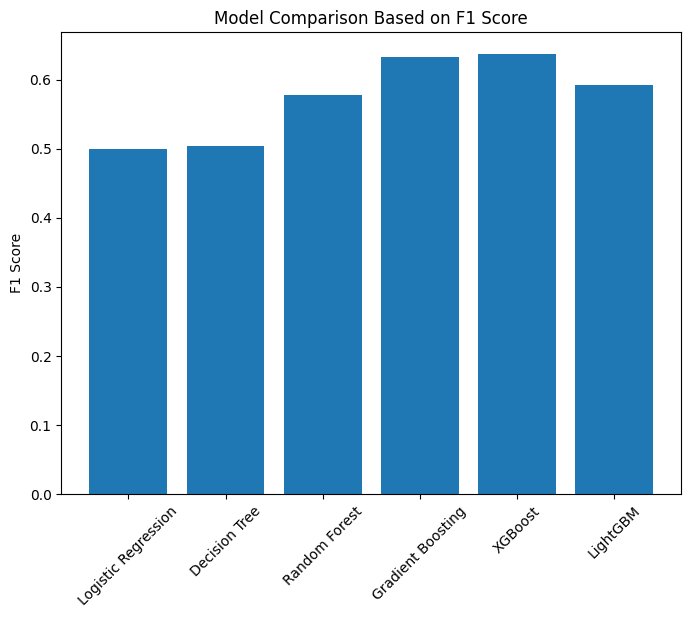

In [503]:
model_f1_scores = {
    "Logistic Regression": f1_score(y_test, y_pred_lr2),
    "Decision Tree": f1_score(y_test, y_pred_dt),
    "Random Forest": f1_score(y_test, y_pred_rf),
    "Gradient Boosting": f1_score(y_test, y_pred_gb),
    "XGBoost": f1_score(y_test, y_pred_adjusted),
    "LightGBM": f1_score(y_test, y_pred)
}
f1_df = pd.DataFrame(list(model_f1_scores.items()), columns=["Model", "F1 Score"])

## Create a bar plot to compare the F1 scores of the models
plt.figure(figsize=(8,6))

plt.bar(f1_df["Model"], f1_df["F1 Score"])

plt.title("Model Comparison Based on F1 Score")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)

plt.show()

In [504]:

# from sklearn.metrics import recall_score
# thresholds = []
# recalls = []

# for t in np.arange(0.1, 0.9, 0.05):
#     y_pred_temp = (y_prob > t).astype(int)
    
#     recall = recall_score(y_test, y_pred_temp)
    
#     thresholds.append(t)
#     recalls.append(recall)

# ## Plotting the recall vs threshold

# plt.figure(figsize=(8,6))

# plt.plot(thresholds, recalls, marker='o')

# plt.xlabel("Threshold")
# plt.ylabel("Recall")
# plt.title("Recall vs Prediction Threshold")

# plt.grid(True)

# plt.show()

## Hyperparameter Tuning

In [505]:
# from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GridSearchCV

In [506]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

param_grid = {
    "max_depth": [3,4,5,6],
    "n_estimators": [100,200,300],
    "learning_rate": [0.01,0.05,0.1],
    "subsample": [0.8,1.0],
    "colsample_bytree": [0.8,1.0],
       "gamma": [0, 0.1, 0.3],
    "min_child_weight": [1, 3, 5]
}

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best parameters:", grid_xgb.best_params_)
print("Best ROC AUC:", grid_xgb.best_score_)

Best parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 0.8}
Best ROC AUC: 0.6225280339938262


In [507]:
## Hyperparameter tuning for Gradient Boosting Classifier using GridSearchCV and SMOTE for handling class imbalance

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', GradientBoostingClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 4, 5],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2, 4]
}

grid_gb = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",   # important since you care about churn detection
    cv=5,
    n_jobs=-1
)
grid_gb.fit(X_train, y_train)

print("Best parameters:", grid_gb.best_params_)
print("Best F1 score:", grid_gb.best_score_)

best_gb = grid_gb.best_estimator_

y_prob = best_gb.predict_proba(X_test)[:,1]

threshold = 0.31
y_pred_gb = (y_prob > threshold).astype(int)
#print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1:", f1_score(y_test, y_pred_gb))


## to get the best threshold for the best model (e.g., Gradient Boosting) to maximize F1 score
# best_model = grid.best_estimator_



# y_prob = best_model.predict_proba(X_test)[:, 1]

# thresholds = np.arange(0.1, 0.9, 0.01)

# f1_scores = []

# for t in thresholds:
#     y_pred = (y_prob > t).astype(int)
#     f1_scores.append(f1_score(y_test, y_pred))

# best_threshold = thresholds[np.argmax(f1_scores)]

# print("Best Threshold:", best_threshold)
# y_pred = (y_prob > best_threshold).astype(int)



Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best F1 score: 0.6178288051106348
Recall: 0.7493857493857494
F1: 0.594541910331384


In [508]:
import pickle
artifact = {
    "model": best_gb,
    "threshold": 0.31
}

with open("models/churn_model.pkl", "wb") as f:
    pickle.dump(artifact, f)

In [509]:

# param_grid = {
#     "n_estimators": [100, 200, 300],
#     "max_depth": [None, 5, 10, 20],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 4],
#     "max_features": ["sqrt", "log2"]
# }
# rf = RandomForestClassifier(random_state=42)

# grid_gb = GridSearchCV(
#     estimator=rf,
#     param_grid=param_grid,
#     scoring="f1",   # important since you care about churn detection
#     cv=5,
#     n_jobs=-1
# )
# grid_gb.fit(X_train, y_train)
# print("Best parameters:", grid_gb.best_params_)
# print("Best F1 score:", grid_gb.best_score_)

# best_gb = grid_gb.best_estimator_

# y_prob = best_gb.predict_proba(X_test)[:,1]

# threshold = 0.35
# y_pred_gb = (y_prob > threshold).astype(int)
# print("Precision:", precision_score(y_test, y_pred_gb))
# print("Recall:", recall_score(y_test, y_pred_gb))
# print("F1:", f1_score(y_test, y_pred_gb))

In [510]:
from sklearn.model_selection import RandomizedSearchCV

# param_dist = {
#     "n_estimators": [100, 200, 300],
#     "learning_rate": [0.01, 0.05, 0.1],
#     "max_depth": [-1, 5, 10],
#     "num_leaves": [31, 50, 70],
#     "subsample": [0.8, 1.0],
#     "colsample_bytree": [0.8, 1.0]
# }
# lgbm = LGBMClassifier(random_state=42)

# random_search = RandomizedSearchCV(
#     estimator=lgbm,
#     param_distributions=param_dist,
#     n_iter=30,          # number of random parameter combinations
#     scoring="f1",       # important for churn prediction
#     cv=5,
#     random_state=42,
#     n_jobs=-1
# )

# random_search.fit(X_train, y_train)
# print("Best parameters:", random_search.best_params_)
# print("Best F1 score:", random_search.best_score_)

## Plotting metrics Recall and F1 Score

In [514]:
model_results = {
    # "Random Forest": {
    #     "Recall": recall_score(y_test, y_pred_rf),
    #     "F1": f1_score(y_test, y_pred_rf)
    # },
    "Gradient Boosting": {
        "Recall": recall_score(y_test, y_pred_gb),
        "F1": f1_score(y_test, y_pred_gb)
    },
    "XGBoost": {
        "Recall": recall_score(y_test, y_pred_adjusted),
        "F1": f1_score(y_test, y_pred_adjusted)
    },
    "LightGBM": {
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }
}

results_plot = results_df.reset_index().rename(columns={"index": "Model"})

fig = px.bar(
    results_plot,
    x="Model",
    y=["Recall (%)", "F1 (%)"],
    barmode="group",
    text_auto=True,
    color_discrete_map={
        "Recall (%)": "#1f77b4",
        "F1 (%)": "#d62728"
    },
    title="Model Comparison Based on Recall and F1 Score"
)
fig.update_layout(
    xaxis_title="Model",
    yaxis_title="Score (%)",
    legend_title_text="",
    xaxis=dict(tickangle=0)
)
fig.show()


# results_df = pd.DataFrame(model_results).T

# results_df["Recall (%)"] = (results_df["Recall"] * 100).round(2)
# results_df["F1 (%)"] = (results_df["F1"] * 100).round(2)

# results_df = results_df.sort_values(by="Recall (%)", ascending=False)

# results_df[["Recall (%)", "F1 (%)"]].plot(kind="bar", figsize=(8,6), color=["#1f77b4", "#d62728"])

# plt.title("Model Comparison Based on Recall and F1 Score")
# plt.ylabel("Score (%)")
# plt.xticks(rotation=0)
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# plt.tight_layout()  

# plt.show()

## Feauture importance plot

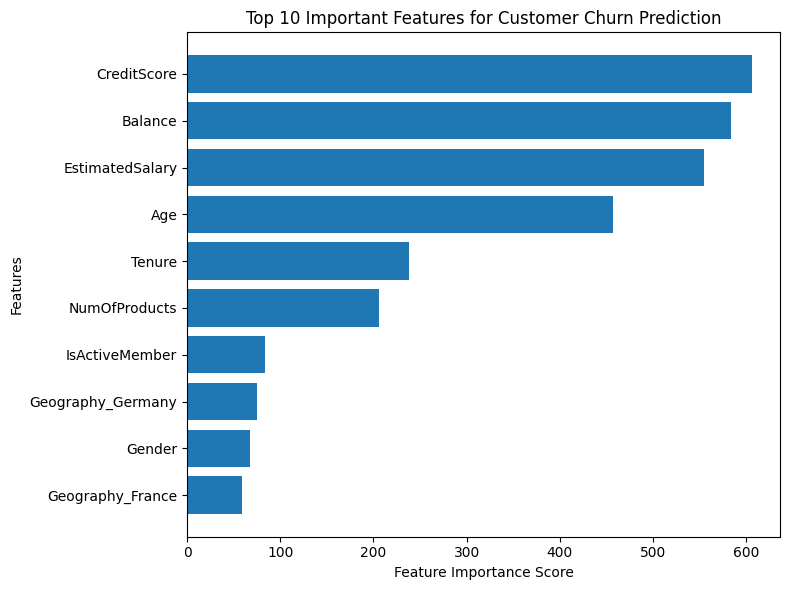

In [513]:
 #get feature importance
importance = lgbm.feature_importances_

# create dataframe
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

# Sort feature importance
feature_importance = feature_importance.sort_values(by="Importance", ascending=True)

# Take top 10 features
top_features = feature_importance.tail(10)

plt.figure(figsize=(8,6))

plt.barh(top_features["Feature"], top_features["Importance"])

plt.title("Top 10 Important Features for Customer Churn Prediction")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()